In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from fpppy.utils import plot_series
from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL
import tsfeatures as tsf    

### O código do livro - Cap4

In [14]:
aus_tourism=pd.read_csv("../data/aus_tourism.csv", parse_dates=["ds"])
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].mean()
mean_df.sort_values(by="y").head(10)

,unique_id,y
158,Kangaroo Island-South Australia-Other,0.340347
182,MacDonnell-Northern Territory-Other,0.449004
294,Wilderness West-Tasmania-Other,0.478268
34,Barkly-Northern Territory-Other,0.632386
86,Clare Valley-South Australia-Other,0.897749
38,Barossa-South Australia-Other,1.021521
154,Kakadu Arnhem-Northern Territory-Other,1.042653
170,Lasseter-Northern Territory-Other,1.135796
298,Wimmera-Victoria-Other,1.146237
183,MacDonnell-Northern Territory-Visiting,1.175393


Aqui eu mudei a ordenação e inclui as 20 maiores médias

In [15]:
mean_df.sort_values(by="y", ascending=False).head(20)

,unique_id,y
271,Sydney-New South Wales-Visiting,747.269968
203,Melbourne-Victoria-Visiting,618.897541
268,Sydney-New South Wales-Business,602.043884
217,North Coast NSW-New South Wales-Holiday,587.896632
269,Sydney-New South Wales-Holiday,550.326865
129,Gold Coast-Queensland-Holiday,528.339881
201,Melbourne-Victoria-Holiday,507.282271
257,South Coast-New South Wales-Holiday,495.058858
51,Brisbane-Queensland-Visiting,492.806132
200,Melbourne-Victoria-Business,477.978182


Criando a descrição dos dados

In [16]:
mean_df.describe()

,y
count,304.000000
mean,70.896448
std,114.884094
min,0.340347
25%,8.337351
50%,28.306878
75%,79.890723
max,747.269968


Criando a visualização da descrição


<Axes: >

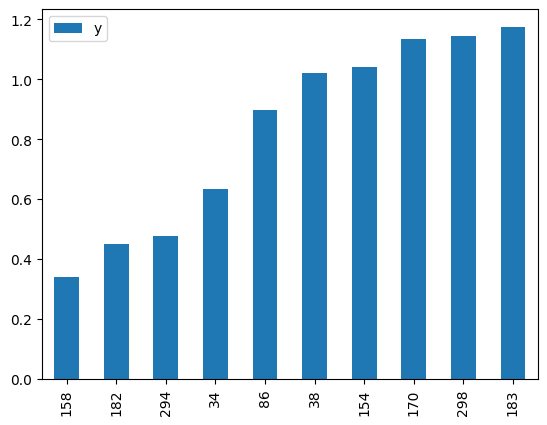

In [17]:
mean_df.sort_values(by="y").head(10).plot.bar()

### Aproveitando o código para ir estudando, demonstrar utras métricas nos dados

Soma (Total de hóspedes)

In [19]:
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].sum()
mean_df.sort_values(by="y", ascending=False).head(10)

,unique_id,y
271,Sydney-New South Wales-Visiting,59781.597453
203,Melbourne-Victoria-Visiting,49511.803281
268,Sydney-New South Wales-Business,48163.510696
217,North Coast NSW-New South Wales-Holiday,47031.730539
269,Sydney-New South Wales-Holiday,44026.149221
129,Gold Coast-Queensland-Holiday,42267.190473
201,Melbourne-Victoria-Holiday,40582.581653
257,South Coast-New South Wales-Holiday,39604.708648
51,Brisbane-Queensland-Visiting,39424.490579
200,Melbourne-Victoria-Business,38238.254520


Mínimo (Piores dias)

In [20]:
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].min()
mean_df.sort_values(by="y", ascending=False).head(10)

,unique_id,y
271,Sydney-New South Wales-Visiting,516.805798
203,Melbourne-Victoria-Visiting,446.083344
269,Sydney-New South Wales-Holiday,409.743041
217,North Coast NSW-New South Wales-Holiday,398.308092
129,Gold Coast-Queensland-Holiday,373.189660
268,Sydney-New South Wales-Business,355.022697
51,Brisbane-Queensland-Visiting,326.696731
201,Melbourne-Victoria-Holiday,324.761322
200,Melbourne-Victoria-Business,311.787918
265,Sunshine Coast-Queensland-Holiday,304.504624


Máximo (Melhores dia)

In [21]:
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].max()
mean_df.sort_values(by="y", ascending=False).head(10)

,unique_id,y
203,Melbourne-Victoria-Visiting,985.278401
268,Sydney-New South Wales-Business,948.129364
271,Sydney-New South Wales-Visiting,920.775880
257,South Coast-New South Wales-Holiday,914.772832
217,North Coast NSW-New South Wales-Holiday,905.845001
269,Sydney-New South Wales-Holiday,828.317118
201,Melbourne-Victoria-Holiday,806.161435
51,Brisbane-Queensland-Visiting,796.302063
129,Gold Coast-Queensland-Holiday,711.037236
200,Melbourne-Victoria-Business,704.055654


std (o quão instável é o movimento)

In [22]:
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].std()
mean_df.sort_values(by="y", ascending=False).head(10)

,unique_id,y
257,South Coast-New South Wales-Holiday,169.955298
217,North Coast NSW-New South Wales-Holiday,117.022653
268,Sydney-New South Wales-Business,116.766078
137,Great Ocean Road-Victoria-Holiday,115.883132
201,Melbourne-Victoria-Holiday,102.942085
237,Peninsula-Victoria-Holiday,96.724306
25,Australia's South West-Western Australia-Holiday,95.284332
203,Melbourne-Victoria-Visiting,93.627753
51,Brisbane-Queensland-Visiting,90.632397
271,Sydney-New South Wales-Visiting,89.640462


Analisando a dimensão temporal

In [23]:
aus_tourism["month"] = aus_tourism["ds"].dt.month

aus_tourism.groupby(["unique_id", "month"])["y"].mean()

unique_id                                 month
Adelaide Hills-South Australia-Business   3         2.038584
                                          6         2.546957
                                          9         4.197311
                                          12        1.874092
Adelaide Hills-South Australia-Holiday    3         9.337173
                                                     ...    
Yorke Peninsula-South Australia-Other     12        1.877682
Yorke Peninsula-South Australia-Visiting  3        33.602976
                                          6        27.473143
                                          9        21.021979
                                          12       30.488110
Name: y, Length: 1216, dtype: float64

In [24]:
aus_tourism[aus_tourism["y"] > 100]

,unique_id,ds,y,month
0,Adelaide-South Australia-Business,1998-03-31,135.077690,3
1,Adelaide-South Australia-Business,1998-06-30,109.987316,6
2,Adelaide-South Australia-Business,1998-09-30,166.034687,9
3,Adelaide-South Australia-Business,1998-12-31,127.160464,12
4,Adelaide-South Australia-Business,1999-03-31,137.448533,3
...,...,...,...,...
24140,Yorke Peninsula-South Australia-Holiday,2013-03-31,126.466076,3
24144,Yorke Peninsula-South Australia-Holiday,2014-03-31,117.020109,3
24151,Yorke Peninsula-South Australia-Holiday,2015-12-31,111.149511,12
24152,Yorke Peninsula-South Australia-Holiday,2016-03-31,130.937233,3


In [25]:
mean_df.sort_values(by=["y", "unique_id"], ascending=[False, True])

,unique_id,y
257,South Coast-New South Wales-Holiday,169.955298
217,North Coast NSW-New South Wales-Holiday,117.022653
268,Sydney-New South Wales-Business,116.766078
137,Great Ocean Road-Victoria-Holiday,115.883132
201,Melbourne-Victoria-Holiday,102.942085
...,...,...
86,Clare Valley-South Australia-Other,1.534990
34,Barkly-Northern Territory-Other,1.371196
294,Wilderness West-Tasmania-Other,1.347861
182,MacDonnell-Northern Territory-Other,1.004042


In [26]:
aus_tourism.groupby("unique_id").apply(
    lambda x: x.sort_values("y", ascending=False).head(3)
)

C:\Users\vanma\AppData\Local\Temp\ipykernel_8980\706077332.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aus_tourism.groupby("unique_id").apply(


unique_id  \
unique_id                                                                                  
Adelaide Hills-South Australia-Business  346     Adelaide Hills-South Australia-Business   
                                         390     Adelaide Hills-South Australia-Business   
                                         392     Adelaide Hills-South Australia-Business   
Adelaide Hills-South Australia-Holiday   410      Adelaide Hills-South Australia-Holiday   
                                         461      Adelaide Hills-South Australia-Holiday   
...                                                                                  ...   
Yorke Peninsula-South Australia-Other    24234     Yorke Peninsula-South Australia-Other   
                                         24236     Yorke Peninsula-South Australia-Other   
Yorke Peninsula-South Australia-Visiting 24263  Yorke Peninsula-South Australia-Visiting   
                                         24317  Yorke Peninsula-South Australia-Visiting   
                                         24308  Yorke Peninsula-South Australia-Visiting   

                                                       ds          y  month  
unique_id                                                                    
Adelaide Hills-South Australia-Business  346   2004-09-30  28.601515      9  
                                         390   2015-09-30  16.273303      9  
                                         392   2016-03-31  14.685726      3  
Adelaide Hills-South Australia-Holiday   410   2000-09-30  35.751337      9  
                                         461   2013-06-30  24.249371      6  
...                                                   ...        ...    ...  
Yorke Peninsula-South Australia-Other    24234 2016-09-30   8.121110      9  
                                         24236 2017-03-31   6.854255      3  
Yorke Peninsula-South Australia-Visiting 24263 2003-12-31  56.202511     12  
                                         24317 2017-06-30  50.582837      6  
                                         24308 2015-03-31  50.153863      3  

[912 rows x 4 columns]

Analisando séries temporais 

In [29]:
summary_stats = tsf.tsfeatures(aus_tourism,
    freq=4, features=[tsf.statistics], scale=False)
summary_stats[["unique_id", "min", "p25", "median", "p75", "max"]].head(10)

,unique_id,min,p25,median,p75,max
0,Adelaide Hills-South Australia-Business,0.000000,0.000000,1.255434,3.920368,28.601515
1,Adelaide Hills-South Australia-Holiday,0.000000,5.767673,8.515966,14.059997,35.751337
2,Adelaide Hills-South Australia-Other,0.000000,0.000000,0.907595,2.093167,8.953163
3,Adelaide Hills-South Australia-Visiting,0.777638,8.907923,12.206619,16.806339,81.102109
4,Adelaide-South Australia-Business,68.725393,133.893462,152.576618,176.935536,242.494368
5,Adelaide-South Australia-Holiday,108.033040,134.626822,153.945007,172.256676,223.557406
6,Adelaide-South Australia-Other,25.901846,43.865901,53.809463,62.523135,107.494657
7,Adelaide-South Australia-Visiting,136.611154,178.915998,205.581736,229.299111,269.535618
8,Alice Springs-Northern Territory-Business,1.008425,9.133369,13.324161,18.456365,34.077065
9,Alice Springs-Northern Territory-Holiday,2.808555,16.850803,31.523782,44.784402,76.541382


#### Treinando - Ordenar pelas séries com maior mediana

Meu código

In [33]:
summary_stats = tsf.tsfeatures(aus_tourism,
    freq=4, features=[tsf.statistics], scale=False)
summary_stats.sort_values(by="median", ascending=False)[["unique_id", "median"]].head(5)

,unique_id,median
271,Sydney-New South Wales-Visiting,756.873222
203,Melbourne-Victoria-Visiting,616.704310
268,Sydney-New South Wales-Business,601.364582
217,North Coast NSW-New South Wales-Holiday,569.756142
269,Sydney-New South Wales-Holiday,535.645748


Código do ChatGPT

In [34]:
summary_stats = tsf.tsfeatures(
    aus_tourism,
    freq=4,
    features=[tsf.statistics],
    scale=False
)

top_5 = (
    summary_stats
    .sort_values(by="median", ascending=False)
    [["unique_id", "median"]]
    .head(5)
)

In [35]:
top_5

,unique_id,median
271,Sydney-New South Wales-Visiting,756.873222
203,Melbourne-Victoria-Visiting,616.704310
268,Sydney-New South Wales-Business,601.364582
217,North Coast NSW-New South Wales-Holiday,569.756142
269,Sydney-New South Wales-Holiday,535.645748


#### Treinando - Quais as séries mais instáveis

Usando range = max - min

In [38]:
summary_stats["range"] = summary_stats["max"] - summary_stats["min"]
top_5_ranges = summary_stats.sort_values(by="range", ascending=False)[["unique_id", "range"]].head(5)
top_5_ranges

,unique_id,range
257,South Coast-New South Wales-Holiday,646.611478
268,Sydney-New South Wales-Business,593.106666
203,Melbourne-Victoria-Visiting,539.195057
217,North Coast NSW-New South Wales-Holiday,507.536908
201,Melbourne-Victoria-Holiday,481.400112


Usando std - desvio padrão

In [48]:
#pegar os 5 hotéis com movimento mais instáveis usando desvio padrão

summary_stats["std"] = summary_stats["variance"] ** 0.5
summary_stats.sort_values(by="std", ascending=False)[["unique_id", "std"]].head(5)

,unique_id,std
257,South Coast-New South Wales-Holiday,169.955298
217,North Coast NSW-New South Wales-Holiday,117.022653
268,Sydney-New South Wales-Business,116.766078
137,Great Ocean Road-Victoria-Holiday,115.883132
201,Melbourne-Victoria-Holiday,102.942085


In [50]:
summary_stats["cv"] = summary_stats["std"] / summary_stats["mean"]
summary_stats.sort_values(by="cv", ascending=False)[["unique_id", "cv"]].head(5)

,unique_id,cv
294,Wilderness West-Tasmania-Other,2.818211
158,Kangaroo Island-South Australia-Other,2.488575
182,MacDonnell-Northern Territory-Other,2.236152
34,Barkly-Northern Territory-Other,2.168291
298,Wimmera-Victoria-Other,1.912936
